In [1]:
%pip install -q joblib scikit-learn pandas matplotlib numpy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ruta = Path("..")
datos = pd.read_csv(ruta / "data" / "beisbol.csv")
datos = datos.drop(columns=[c for c in datos.columns if c.startswith("Unnamed")])
datos.head()

,equipos,bateos,runs
0,Texas,5659,855
1,Boston,5710,875
2,Detroit,5563,787
3,Kansas,5672,730
4,St.,5532,762


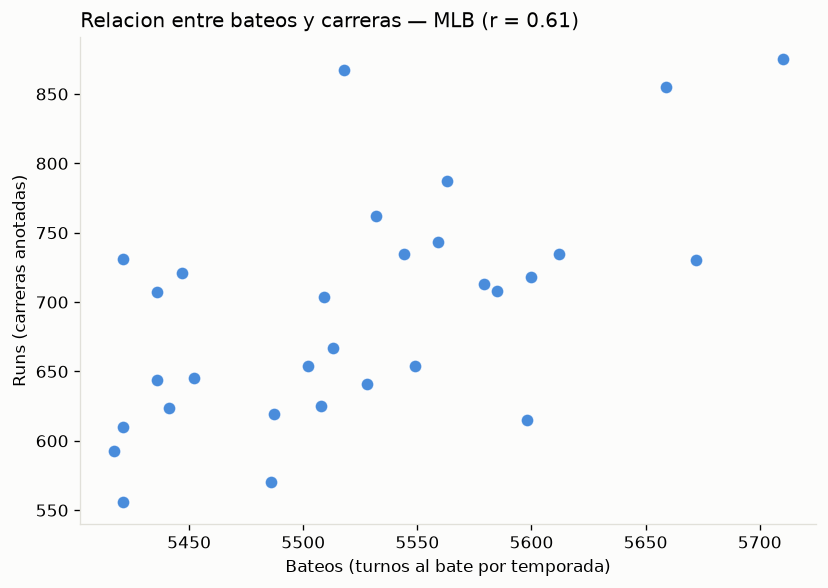

In [3]:
BLUE = "#2a78d6"
ORANGE = "#eb6834"
MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
})

correlacion = datos["bateos"].corr(datos["runs"])
fig, ax = plt.subplots(figsize=(7, 5), dpi=120)
ax.scatter(datos["bateos"], datos["runs"], s=60, color=BLUE, alpha=0.85,
           edgecolor="white", linewidth=0.8, zorder=3)
ax.set_xlabel("Bateos (turnos al bate por temporada)")
ax.set_ylabel("Runs (carreras anotadas)")
ax.set_title(f"Relacion entre bateos y carreras — MLB (r = {correlacion:.2f})", loc="left")
fig.tight_layout()
fig.savefig(ruta / "figures" / "de_beisbol_dispersion.png", facecolor=SURFACE)
plt.show()

In [4]:
x = datos[["bateos"]]
y = datos["runs"]

x_entrena, x_prueba, y_entrena, y_prueba = train_test_split(
    x, y, test_size=0.2, random_state=42
)
validacion = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"Entrenamiento: {x_entrena.shape[0]} equipos | Prueba: {x_prueba.shape[0]} equipos")

Entrenamiento: 24 equipos | Prueba: 6 equipos


In [5]:
rejilla = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 4, None],
    "min_samples_leaf": [1, 2, 4],
}

busqueda = GridSearchCV(
    RandomForestRegressor(random_state=42), rejilla, cv=validacion,
    scoring="r2", n_jobs=-1
)
busqueda.fit(x_entrena, y_entrena)

print("Mejores hiperparametros:", busqueda.best_params_)
print("Mejor R2 (CV, train):", round(busqueda.best_score_, 3))

modelo_final = busqueda.best_estimator_
pred_final = modelo_final.predict(x_prueba)

scores_cv = cross_val_score(modelo_final, x, y, cv=validacion, scoring="r2")
print("R2 por fold (validacion cruzada, 5-fold):", np.round(scores_cv, 3))
print("R2 promedio (CV):", round(scores_cv.mean(), 3))

Mejores hiperparametros: {'max_depth': 2, 'min_samples_leaf': 4, 'n_estimators': 50}
Mejor R2 (CV, train): 0.214
R2 por fold (validacion cruzada, 5-fold): [-0.483  0.279  0.363 -0.301 -0.381]
R2 promedio (CV): -0.105


In [6]:
metricas = {
    "R2": r2_score(y_prueba, pred_final),
    "MAE": mean_absolute_error(y_prueba, pred_final),
    "RMSE": mean_squared_error(y_prueba, pred_final) ** 0.5,
}
resultados = pd.DataFrame([metricas]).round(3)
resultados

,R2,MAE,RMSE
0,-0.58,54.952,73.716


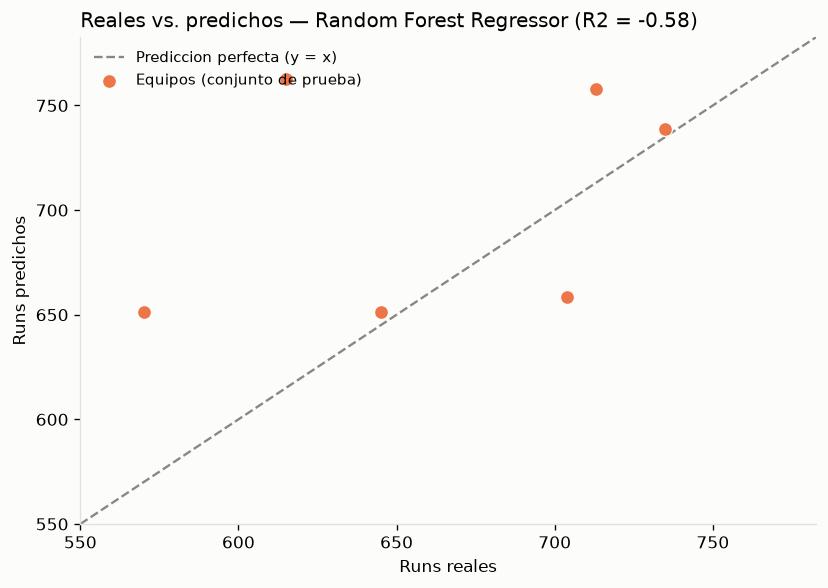

In [7]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=120)
lims = [min(y_prueba.min(), pred_final.min()) - 20, max(y_prueba.max(), pred_final.max()) + 20]
ax.plot(lims, lims, color=MUTED, linestyle="--", linewidth=1.4, label="Prediccion perfecta (y = x)")
ax.scatter(y_prueba, pred_final, s=70, color=ORANGE, alpha=0.9,
           edgecolor="white", linewidth=0.8, zorder=3, label="Equipos (conjunto de prueba)")
ax.set_xlabel("Runs reales")
ax.set_ylabel("Runs predichos")
ax.set_title(f"Reales vs. predichos — Random Forest Regressor (R2 = {metricas['R2']:.2f})", loc="left")
ax.legend(frameon=False, loc="upper left", fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)
fig.tight_layout()
fig.savefig(ruta / "figures" / "de_beisbol_real_vs_predicho.png", facecolor=SURFACE)
plt.show()

In [8]:
joblib.dump(modelo_final, ruta / "models" / "de_random_forest_beisbol.joblib")
print("Modelo guardado en la carpeta models/")

Modelo guardado en la carpeta models/
